<h1 id="tocheading">Estudio de Interconección SAEB</h1>
<div id="toc"></div>

> Para determinar la viabilidad técnica de la integración de tecnologías de bajas emisiones de carbono, como ciertos Recursos Energéticos Distribuidos o Dispersos (DER), a saber: Vehículos Eléctricos, Paneles Fotovoltaicos (a gran o pequeña escala) y Sistemas de Almacenamiento, es menester llevar a cabo un estudio de *interconexión* para la identificación y evaluación de vulnerabilidades en la red desbalanceada y, con ello, si amerita, la reesquematización de la misma, ya sea a media o baja tensión.

A pesar de que la *Respuesta a la Demanda* pueda entenderse conceptualmente también como otro DER (agregado o no), este estudio no la contempla; más bien, busca levantar escenarios que sometan a estrés al sistema, avanzando en una penetración paulatina. Para ello, se utiliza un algoritmo que computa la capacidad de alojabilidad [1], basado en modelo, con énfasis en diferencias de tensión y corrientes de cortocircuito. Se dirá que el *caso base* es aquel cuya penetración es nula, es decir, el estado actual de la red incluyendo su generación distribuida inicial. En tanto, el *caso DER* incorpora, en la cola del circuito de media tensión —donde nacen otros dos circuitos—, un Sistema de Almacenamiento de Energía con Batería (SAEB).


## Contenido
* [Topología y Conectividad de la red de distribución](#first-section)
* [Calibración del modelo](#second-section)
* [Intergración del DER (SAEB)](#der-innerconnection)
* [Análisis de pérdidas técnicas](#third-section)
* [Perfiles de tensión](#voltage-profile)
    - [Líneas críticas](#critical-branches)
    - [Aumento de tensión](#delta-voltage)
* [Estudio de fallas](#fourth-section)
    - [Fallas en media tensión](#mv-faults)
    - [Fallas en baja tensión](#lv-faults)
* [Curvas de tiempo para coordinación de protecciones](#protection-curves)
* [Conclusiones](#end)
* [Referencias y Documentación](#references)

---

## Topología y Conectividad de la red de distribución <a class="anchor" id="first-section"></a>

En el marco eléctrico, la red de distribución en cuestión es un circuito desbalanceado no mallado, modelado en OpenDSS [2] con zonas trifásicas y monofásicas. Aunque cuenta con elementos de protección e.g Interruptores y fusibles no cuenta con elementos de regulación de tensión estrictos e.g. Autotransformadores, Bancos de Capacitores, Condensadores síncronos. El circuito discurre desde la subestación modelada como un transformador trifásico de tres devanados pasa por cargas monofásicas de baja tensión y desemboca en aquella barra (patio de interruptores) en la que convergen otros dos circuitos pero que son representados como dos cargas concentradas, trifásicas de media tensión cada una, de potencia activa y reactiva constante.

En el marco topológico el circuito es una red *radial*, es decir, un árbol cuya raíz es la fuente y cuyas hojas son las cargas. Se sabe por teoría de grafos que un árbol por definición no tiene ciclos, anillos o lazos por tanto la diferencia entre la cardinalidad de los vertices (barras) y aristas (ramas) es **uno** dado que una arista es la unión de dos vértices. Tras contar barras y ramas se obtiene 2304 y 2303 respectivamente, luego el criterio se satisface y la red es radial como se desea.

*Nota*: Las ramas pueden ser transformadores, líneas, etc. Es decir cualquier elemento que vaya de una barra a otra independientemente de los *nodos* de la barra a los que tal o cual terminal del elemento se conecta. De tal manera que los bancos de transformadores equivalen a una sóla rama así como cualquier transformador monofásico de tres devandos. Se asumió que la barra terciaria de la subestación no está energizada.

Se dice que un grafo está conectado si el número de componentes es único, o sea, si para cualesquiera vértices existe una ruta no trivial (tren de aristas o vértices) que los une. Luego un algoritmo de recorrido del grafo, debería recorrer todos los vértices a partir de un único vértice inicial arbitrario. Cuando de una red eléctrica se trata es más natural recorrerla por profundidad que por anchura, así se implementa un *Depth First Search* (DFS) para evualuar la conectividad. Como se comtempla que el número de barras recorridas coinciden con el número de vértices de modo que se cumple el criterio y se demuestra que la red está conectada.

In [1]:
import host as ht

gis_ckt = ht.GISCircuit(gis_path="./GIS-2203/*.shp")
ckt_map = gis_ckt.explore_ckt()
ckt_map
# ckt_map.save("ckt.html")

EmptyGeoDataFrame: No values in LoadsMV.


In [2]:
base_ckt = ht.BaseCicuit(
    ckt_path="./2203/2203_Master.dss"
)
graph = ht.CktGraph(base_ckt)

print("|Buses|: ", len(graph.vertices))
print("|Branches|: ", len(graph.edges))


|Buses|:  2304
|Branches|:  2303


In [3]:
tree_branches = []
for branch in graph.dfs_edges():
    tree_branches.append(branch)

n_vertices = len(tree_branches) + 1
print(n_vertices)

2304


In [4]:
buses = []
with open("./2203/2203_CoordinatesBusesLV.csv", "r") as file:
    for line in file:
        if line:
            bus = line.split(",")[0].lower()
            buses.append(bus)

with open("./2203/2203_CoordinatesBusesMV.csv", "r") as file:
    for line in file:
        if line:
            bus = line.split(",")[0].lower()
            buses.append(bus)

print(len(buses))

for bus in graph.vertices:
    if bus not in buses:
        print(bus)

2299
sourcebus
buslvnoe51b9e81-7791-4bb7-bf7e-49b01eb7ccf5cplvpcn
buslvno95968b65-b0bf-442e-b14f-871b85cd66b6cplvpcn
buslvno922a8285-f135-4266-abbb-5f29fe995080cplvpcn
buslvno7149c81b-d061-4f04-a1c5-d969ae1e124acplvpcn


## Calibración del modelo <a class="anchor" id="second-section"></a>

La demanda medida durante un período típico de 24 horas se compara con la demanda simulada (virtual) del caso base. Como muestra la figura [ ], el estrecho comportamiento entre ambas respalda la calibración del modelo del caso base utilizado en el estudio de interconexión. De hecho, se asemejan tanto que resulta inusual, y esto se debe a dos cargas de media tensión relativamente dominantes que, en realidad, condensan dos circuitos mayores.

Salta a la vista que la demanda del caso base virtual está algo sobredimensionada y, aunque se pudieron haber ajustado sus curvas de demanda para lograr una mayor precisión, conviene, sin embargo, en estos estudios, simular situaciones desfavorables o más severas que las normales, con el fin de obtener mayores márgenes de seguridad y dimensionamientos más robustos.

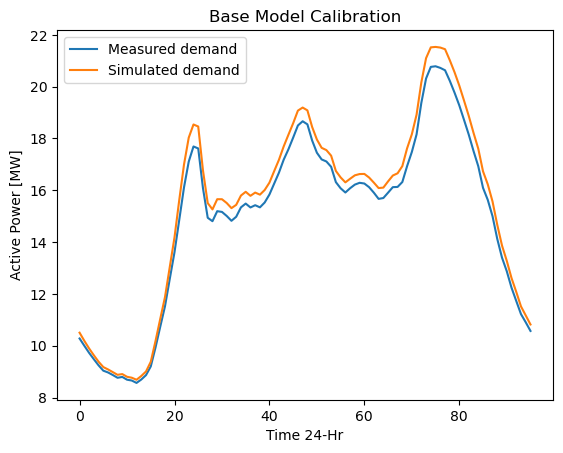

In [5]:
import pandas as pd

df = pd.read_csv("./profiles.csv")
measurements_df = df[df["ID"] == 2203][:-1]['Potencia_activa'].values

base_losses = base_ckt.calculate_losses()

ht.plt.plot(
    measurements_df * 1e-3,
    label="Measured demand"
)
ht.plt.plot(
    base_ckt.feeders_power[:, 0] * 1e-3,
    label="Simulated demand"
)
ht.plt.title("Base Model Calibration")
ht.plt.xlabel("Time 24-Hr")
ht.plt.ylabel("Active Power [MW]")

ht.plt.plot()
ht.plt.legend()
ht.plt.show()


Efectivamente, la potencia pico representativa de referencia es de 20.80 [MW], mientras que la virtualmente obtenida es de 21.53 [MW]. Para los análisis posteriores se utilizará esta última, la cual sostiene un consumo diario acumulado $S_{net}$ de (1480.92, 129.12) [MW, MVAr].

In [6]:
print(
    "Actual peak [MW]",
    max(measurements_df*1e-3)
)
print(
    "Base peak [MW]",
    max(base_ckt.feeders_power[:, 0]*1e-3)
)

Actual peak [MW] 20.786240000000003
Base peak [MW] 21.53283984375


In [7]:
active_p = sum(base_ckt.feeders_power[:, 0]*1e-3)
reactive_q = sum(base_ckt.feeders_power[:, 1]*1e-3)
complex_power = active_p + 1j*reactive_q
print("Apparent base power [MW, MVAr]: ", complex_power)

Apparent base power [MW, MVAr]:  (1480.9194433593752+129.11827197265626j)


## Intergración *DER* al sistema <a class="anchor" id="der-innerconnection"></a>

Un SAEB es una clase de *DER* pero que en lontananza parece un generador, de hecho en OpenDSS es una extensión del objecto *Generador* pero con inversor, la dinámica de éste componente luego presentará algunos retos en condiciones de falla como se verá más adelante.

También merece la pena desentrañar los diferentes tipos de pérdidas involucadas en el modelo, a saber, la eficiencia del inversor ($\eta_{inv}$) que no se define explícitamente como un único parámetro en cambio, se incluye en las propiedades `%EffCharge` y `%EffDischarge`, que representan la eficiencia de carga y descarga, además de incluir las pérdidas internas e.g. térmicas o de cableado. La que sí se pueden definir por aparte son las pérdida de reposo, `%IdlingkW` incluso sin carga ni descarga, análogas a la corriente de magnetización de un trasformador.

- Modelo de potencia de carga efectiva.

$$
\boxed{

    P_{eff}^{ch} = \left(P_{in}\eta_{inv} - P_{idl} \right) \cdot \eta_{ch}
}
$$

donde $P_{idl}$ es conocido, y corresponde al consumo constante por ocio (reposo).

- Modelo de potencia de descarga efectiva.

$$
P_{eff}^{dch} = P_{out} + P_{\text{losses, tot}}^{dch}
$$

donde $P_{\text{losses, tot}}^{dch}$ equivale a las pérdidas por *Inversor*, *Ocio* e *Internas*, en cuanto a la primera con eficiciencia de $\eta_{inv}$:

$$
P_{\text{loss, inv}}^{dch} = P_{\text{desired}}^{inv} - P_{out}
$$

Y en cuanto a las Internas con eficiencia de $\eta_{dch}$:

$$
P_{\text{losses, dch}} = P_{\text{desired}}^{dch} - \hat{P}_{out}
$$

donde $\hat{P}_{out}$ suple tanto $P_{\text{desired}}^{inv}$ como $P_{idl}$, sea

$$
\eta_{inv} = \frac{P_{out}}{P_{\text{desired}}^{inv}}
$$

entonces

$$
P_{\text{desired}}^{inv} = \frac{P_{out}}{\eta_{inv}}
$$

Luego

$$
P_{\text{loss, inv}}^{dch} = P_{out}\left(\frac{1}{\eta_{inv}} -1 \right)
$$

por otro lado 

$$
\eta_{dch} = \frac{\hat{P}_{out}}{P_{\text{desired}}^{dch}}
$$

o sea

$$
P_{\text{desired}}^{dch} = \frac{\hat{P}_{out}}{\eta_{dch}}
$$

reescribiendo pérdidas internas

$$
P_{\text{losses, dch}} = \frac{\hat{P}_{out}}{\eta_{dch}} - \hat{P}_{out}
$$

Factorizando

$$
P_{\text{losses, dch}} = \hat{P}_{out} \left (\frac{1}{\eta_{dch}} - 1 \right)
$$

o bien

$$
P_{\text{losses, dch}} = \left ( P_{\text{desired}}^{inv} + P_{idl} \right) \left (\frac{1}{\eta_{dch}} - 1 \right)
$$

Finalmente las pérdidas internas de descarga

$$
P_{\text{losses, dch}} = \left ( \frac{P_{out}}{\eta_{inv}} + P_{idl} \right) \left (\frac{1}{\eta_{dch}} - 1 \right)
$$

Así la potencia de descarga efectiva

$$
P_{eff}^{dch} = P_{out} + P_{\text{losses, dch}} + P_{idl} + P_{\text{loss, inv}}^{dch}
$$

Evaluando y simplificando:

$$
\boxed{
    P_{eff}^{dch} = \frac{P_{out}}{\eta_{inv}\eta_{dch}} + \frac{P_{idl}}{\eta_{dch}}
}
$$

El primer término representa la energía que realmente debe extraerse del sistema (desde la batería) para lograr $P_{out}$ útil, considerando las dos eficiencias en cascada mientras que el otro representa el efecto del consumo por ocio $P_{idl}$, también penalizado por la eficiencia de descarga.

En términos prácticos, si se asignase una potencia de 5[MW] y de 20[MWh] de capacidad energética al elemento de almacenamiento cuyo estado de carga inicial es del 6% de su capacidad de energía nominal (1.2 [MWh]), con pérdidas del 1% de la potencia asignada por ocio ((i.e. 50 [kW])) con eficiencias $\eta_{ch}$ y $\eta_{dch}$ del 97% y un $\eta_{inv}$ del 98% (tal que sea alrededor del 95% entre ambas) se tendría una potencia de carga efectiva del 4.7[MW] y asumiendo una ventana de cuatro horas de carga, se tendrían 18.8[kWh] adicionales al estado de carga inicial, o sea el elemento a penas queda cargado.

Si se asume que doce horas después se descarga, el estado actual de carga sería 19.4 [MWh] por culpa del letargo, de los cuales sólamente 18.0 [MWh] son despachables (si se quiere un 7.0% de reserva al final o sea 1.40[MWh]), luego la descarga de potencia efectiva sería 5.3 [MW] de modo que el elemento termina drenado en poco más de tres horas y 20 minutos. Finalmente el SAEB pasará las próximas cuatro horas y 36 minutos en resposo (con fuga por ocio de 230.55[kWh]), hasta la 1am del siguiente día en que el ciclo comience de nuevo, para entonces el reservorio estará a 1.2 [kWH] es decir, al nivel en que comenzó. Y así repetidamente.


Se define a continuación el Sistema de Almacenamiento de Energía por Batería (SAEB), el cual consta de la siguientes características técnicas:

| Parámetro                             | Argumento                                   |
| ------------------------------------- | ------------------------------------------- |
| **Nombre**                            | `mv_battery`                                |
| **Barra de conexion**                 | `BUSMVnSP_1303`                             |
| **Fases**                             | 3                                           |
| **Tensión Nominal**                   | 34.5 [kV]                                   |
| **Potencia Asignada**                 | 5000 [kW] (5 MW)                            |
| **Capacidad de Energía**              | 20000 [kWh] (20 MWh)                        |
| **Modelo**                            | 1 ($P_\text{out}$ constante)                |
| **Factor de potencia**                | +1.0 en atraso (convención de generador)    |
| **SoC Inicial**                       | 6% (1.20 [MWh])                             |
| **SoC de Reserva**                    | 7% (1.40 [MWh] límite mínimo de descarga)   |
| **Modo de Despacho**                  | `follow`                                    |
| **Eficiencia carga-descarga**         | ≈ 90.25% (ciclo completo)                   |
| **Consumo en ocio (pérdidas)**        | 1%  (50 [kW])                               |
| **Horario de carga**                  | 1am - 5am                                   |
| **Horario de descarga**               | 5pm - 8:24pm                                |


La barra es de media tensión a la cola del circuito, en el punto justo en que nacen otros dos circuitos. El modo de despacho *follow* se refiere a un "seguimiento de carga" cuya lógica de operación (carga y descarga) es impuesta por la curva de despacho diaria. Una eficiencia de ciclo completo se refiere a la ida y vuelta i.e. EfCarga (95%) y EfDescarga (95%), donde éstas eficiencias ya incluyen las del inversor, no obstante las de ocio se dejan en 1% de la capacidad energética asignada, entonces

$$
\eta_{ch}^{ef} \cdot \eta_{dch}^{ef} = \eta_{\text{round-trip}}
$$




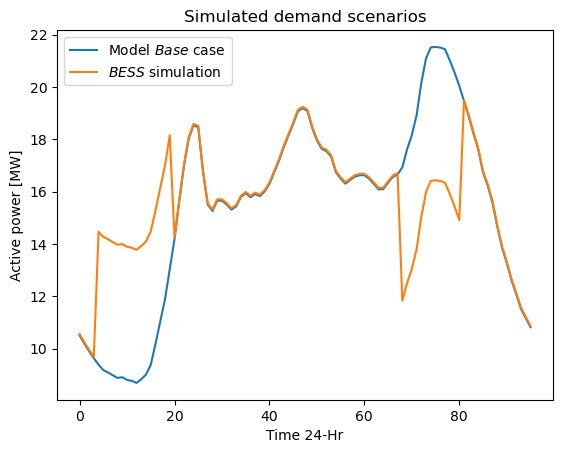

In [8]:
bess_data = [
    {
        "storage_id": "mv_battery",
        "bus_id": "BUSMVnSP_1303",
        "phases": 3,
        "kV": 34.5,
        "kW": 5000.0,
        "kWh": 20000.0,
        "model": 1,
        "per_stored": 6.0,
        "per_reserve": 7.0,
        "dispatch_mode": "follow",
        "daily_id": "dispatch_shape",
        "per_efficiencies": (95.0, 95.0)
    }
]
der_ckt = ht.DERCircuit(
    ckt_path="./2203/2203_Master.dss",
    bess_attrs=bess_data
)
bess_var = der_ckt.get_monitor_data(
    "mv_battery_monitor_9", reset=False
)

der_losses = der_ckt.calculate_losses()

ht.plt.plot(
    base_ckt.feeders_power[:, 0] * 1e-3,
    label=r"Model $Base$ case"
)
ht.plt.plot(
    der_ckt.feeders_power[:, 0] * 1e-3,
    label=r"$BESS$ simulation"
)
ht.plt.title(r"Simulated demand scenarios")
ht.plt.xlabel("Time 24-Hr")
ht.plt.ylabel("Active power [MW]")
ht.plt.legend()
ht.plt.show()

La figura superior [] deja ver un comportamiento esperado de acuerdo a la estrategia de despacho planteda. Y aunque por la cara de potencia activa se ven picos apisonados por la otra cara, la potencia reactiva, también ha de reflejar beneficios en la tensión como ya se verá.

## Análisis de Pérdidas Técnicas <a class="anchor" id="third-section"></a>

Pese a que no se puede hablar de pérdidas de potencia imaginaria $Q$ (VAr) en un sentido estricto, como sí se hace con la potencia real $P$ (W), ya que la primera está asociada al envío (transmisión) o almacenamiento de energía en forma de campo eléctrico (capacitivo) o magnético (inductivo), y salvo que existan condensadores síncronos, generadores subexcitados, etc. —que no es el caso—, dicha potencia no se puede *vaciar* ni disipar como para incurrir en pérdidas reactivas. Más bien, oscila en un ir y venir entre fuente y carga.

No obstante, sí puede modificar el ángulo de carga $\delta$ para una misma potencia aparente $S$, en detrimento o en virtud de la parte real, y por tanto, aumentar o reducir pérdidas activas. Así, mientras un residuo entre potencia activa generada y consumida equivale a pérdidas reales, no sucede lo mismo con un remanente de potencia reactiva. Para apreciar su efecto, se debe evaluar $P$.

Vale una nota respecto a la estrategia de despacho y a propósito de pérdidas no capturadas por el modelo eléctrico: las pérdidas reales durante horas críticas —es decir, momentos de alta demanda— son más costosas económicamente. Además, suelen coincidir con el periodo diurno, cuando la temperatura ambiente es más alta. Este aumento de temperatura, si bien no se contempla en el modelo, agrava físicamente (por efecto Joule) la conductividad y eficiencia de los materiales.

De modo que hay un *doble castigo* escondido. Por ello, es válido y sensato asumir que las pérdidas activas reales son superiores a las aquí reportadas, aunque no de manera significativa, ya que el modelo virtual es algo más severo que el caso verdadero, como se vio en la sección de calibración del modelo. Y en cuanto al impacto económico, el SAEB, al encontrarse más cercano al punto de consumo, debería reducir las pérdidas por caída de tensión durante circunstancias pico, al entrar en acción como respaldo.


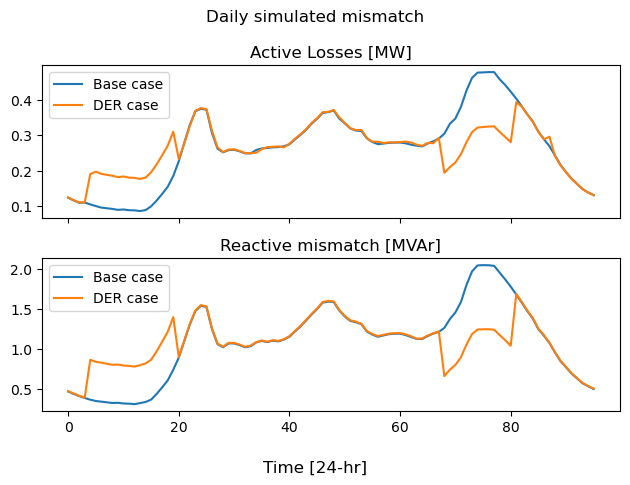

In [9]:
fig, axs = ht.plt.subplots(2, 1, sharex=True)
titles = ["Active Losses [MW]", "Reactive mismatch [MVAr]"]
for n, title in enumerate(titles):
    axs[n].plot(
        base_losses[:, n]*1e-3,
        label="Base case"
    )
    axs[n].plot(
        der_losses[:, n]*1e-3,
        label="DER case"
    )
    axs[n].set_title(title)
    axs[n].legend()

fig.supxlabel("Time [24-hr]")
fig.suptitle("Daily simulated mismatch")
fig.tight_layout()
ht.plt.show()


De la figura anterior [ ], apenas se obtiene una *pintura eléctrica*, pero da pie a la contemplación de beneficios estratégicos en materia de pérdidas técnicas, que conlleva un uniformamiento manifiesto del consumo percibido desde la subestación, tanto en $P$ como en $Q$. En la sección de Tensión se ampliará sobre estos beneficios.

Tras alojar el SAEB, se observa —en términos netos— que este produce una leve cantidad de reactivo (35.47 [VAr]) a lo largo del día, consistente con el hecho de que fue dejado en atraso (bajo convención de generador), debido a la electrónica del inversor. Pese a que se configuró con un factor de potencia unitario, se percibe cierto efecto inductivo, aunque ciertamente despreciable.

Por otra parte, desde la subestación, destaca que hay menor producción de reactivo —un 1% menos—, y si la demanda se mantiene constante, esto se interpreta como un efecto favorable sobre $\delta$, tal que se requiere menos potencia real para suplir la misma carga, implicando menores pérdidas activas. Y de hecho, así es: se reportan 200 [kW] menos de pérdidas activas a lo largo del día (25.50 [MW] en el caso base, lo cual representa un 1.72%, frente a 25.30 [MW] con *DER*, correspondiente al 1.71%; ambos porcentajes relativos a los 1480.92 [MW] diarios generados), sin mencionar la reducción de pérdidas térmicas —con incidencia económica— que no han sido computadas.

Dicho lo anterior, se espera entonces ver, en la siguiente sección, una caída de tensión sutilmente más suave.

In [10]:
print("Reactive net BESS losses [VAr]:", sum(bess_var[:, 3]))
print("\nBase [kVAr]", sum(base_ckt.feeders_power[:, 1]))
print("DER [kVAr]", sum(der_ckt.feeders_power[:, 1]))

Reactive net BESS losses [VAr]: -35.469779399223626

Base [kVAr] 129118.27197265625
DER [kVAr] 128124.25231933594


In [11]:
net_active_base_losses = sum(base_losses[:, 0]) * 1e-3
net_active_der_losses = sum(der_losses[:, 0]) * 1e-3

print(f"Base P[MW]: {net_active_base_losses:.2f}")
print(f"DER P[MW]: {net_active_der_losses:.2f}")


Base P[MW]: 25.50
DER P[MW]: 25.30


## Perfiles de tensión <a class="anchor" id="voltage-profile"></a>

Generalmente se busca que, en el sistema, la tensión no suba o caiga por un margen del |5|% de su capacidad nominal en condiciones de operación usuales y es que al incorporar DER, un SAEB en éste caso, la tensión percibe un cambio. Acontinuación se interpretan los resultados.

Se dirá que una barra está más alejada de la fuente, no por su distancia física (salvo el caso de fallas), sino por su *profundidad* topológica, es decir el nivel en que se encuentra en un recorrido *DFS*, ésto para observar una caída gradual natural (o eso se espera en su tendencia central) de los perfiles de tensión en la medida en que se aleja de su fuente.


### Líneas críticas <a class="anchor" id="critical-branches"></a>

Se hablará de una línea crítica como aquella que al desconectarse aumente el número de componentes de la red. Generalmente son las que tiene interruptores y es menester a su vez conocer y monitorear los estados de tensión en dichos puntos.


In [12]:
switches_at: list[tuple] = []

for n, edge in enumerate(tree_branches):
    if "BUSMVno9C032E89-C69C-4B5C-8401-5AC770FE780Bcp1398205_o66869BDF-E763-43C3-8B9C-3D2B73B7F4EFcpCN".lower() in edge:
        switches_at.append(n)
    elif "BUSMVnoAD23A27D-9BD7-4F84-9D3A-E3A586278A1Fcp1381904_oB2BA01CE-7816-4719-87F6-749301413C5AcpCN".lower() in edge:
        switches_at.append(n)
    elif "BUSMVno0A54A9DA-2B7F-40C6-B2B3-1456FD75A721cp1386329_oDE9DF315-5625-42D4-8DF1-04CF26C18CCEcpCN".lower() in edge:
        switches_at.append(n)
    elif "BUSMVno9DB2829F-E793-44DA-BD12-B0FF1190D6F1cp1374545_oAB8FF8F0-8491-47D0-A9D6-B424F015B98AcpCN".lower() in edge:
        switches_at.append(n)
    elif "BUSMVno20B1C76F-DBB3-478F-82D1-B1F9549164B3cp1308969_o89CAE552-6C1D-40D0-998E-33493DE1EA39cpCN".lower() in edge:
        switches_at.append(n)
    elif "BUSMVno013E50CE-6A64-4CA6-9C96-348F1353577Fcp1293345_o0789DC41-C01A-47C9-A5E5-729E7CD06796cpCN".lower() in edge:
        switches_at.append(n)
    elif "BUSMVno10B4380B-8D0D-4DB7-9155-1DE90A6E7798cp1309072_oC313C4AD-9CC4-4C25-88A3-6E688EB9B27CcpCN".lower() in edge:
        switches_at.append(n)
    elif "BUSMVnoE8548983-C890-45A5-9A36-72E4C925F9AEcp1374971_o35BD0308-E299-424F-8AE0-7B94A4A45EFFcpCN".lower() in edge:
        switches_at.append(n)

switches_at = [
    (switches_at[i], switches_at[i+1])
     for i in range(0, len(switches_at), 2)
]
print(switches_at)

[(1, 2), (32, 33), (54, 55), (115, 116), (312, 313), (493, 494), (1341, 1342), (2299, 2300)]


### Impacto en tensión <a class="anchor" id="delta-voltage"></a>

La figura a continuación [] es un diagrama de caja que delata, en primera instancia, perfiles menos dispersos y, por tanto, más estables bajo el escenario con DER, dado que las cajas del diagrama en este caso son más compactas. Resulta curioso que, en su tendencia media, la tensión aledaña a la subestación en el caso DER se comporte casi igual al caso base, con una discrepancia de apenas 15 [μV]. Sin embargo, al discurrir aguas abajo, acercándose al SAEB, aunque la tensión sigue su caída, esta es más leve en comparación con el caso base, siendo la divergencia más perceptible con 139 [μV] en su valor promedio.

In [13]:
base_vi_data = base_ckt.get_voltage_profiles()
bess_vi_data = der_ckt.get_voltage_profiles()


In [14]:
base_voltages = []
der_voltages = []
elements_id = []
for n, data in enumerate([base_vi_data, bess_vi_data]):
    for monitor_id, vals in data.items():
        obj_id = monitor_id.split("_")[-2]
        if obj_id not in elements_id:
            elements_id.append(obj_id)
        _, vi = vals.shape
        volt_mag_cols = range(2, vi//2 + 1, 2)
        avg_volt_mag = ht.np.sum(vals[:, volt_mag_cols], axis=1) / len(volt_mag_cols)
        volt_mag_pu = avg_volt_mag * 3**0.5 / 34.5e3
        if n == 0:
            base_voltages.append(volt_mag_pu)
        elif n == 1:
            der_voltages.append(volt_mag_pu)

# Alternate (Base1, DER1), (Base2, DER2) ...
groups_data = [] # Combine into a list for plotting
for base_v, der_v in zip(base_voltages, der_voltages):
    groups_data.append(base_v)
    groups_data.append(der_v)


In [15]:
delta_head = groups_data[0] - groups_data[1]
delta_tail = groups_data[-2] - groups_data[-1]

print("mean delta head: ", ht.np.mean(delta_head) * 1e6)
print("mean delta tail: ", ht.np.mean(delta_tail) * 1e6)

mean delta head:  15.294179320335388
mean delta tail:  138.86082160752267


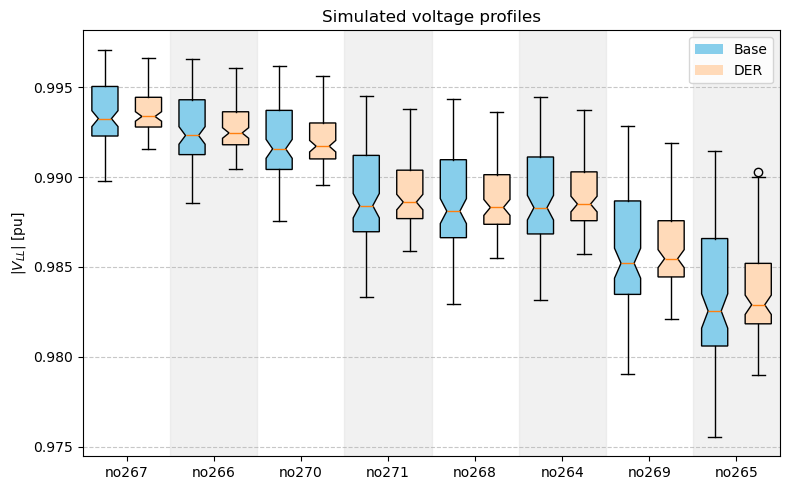

In [16]:
from matplotlib.patches import Patch

# Sample placeholder
# groups_data = [base1, der1, base2, der2]
# elements_id = ["LINE1", "LINE2"]

fig, ax = ht.plt.subplots(figsize=(8, 5))

# Shade background **per element group**
# Each element occupies two x positions: [1, 2] for LINE1, [3, 4] for LINE2
element_groups = [
    (i, i+1) for i in range(1, len(groups_data) + 1, 2)
]

# Color each box
colors = ['skyblue', 'peachpuff']  # lightgreen

# Shade only for even-indexed elements (starting from index 0)
for i, (start, end) in enumerate(element_groups):
    colors += colors
    if i % 2 == 1:  # i == 1 for LINE2
        ax.axvspan(
            start - 0.5,
            end + 0.5,
            color='lightgrey',
            alpha=0.3,
            zorder=0
        )

# Draw boxplot
box = ax.boxplot(
    groups_data,
    patch_artist=True,
    widths=0.6,
    notch=True,
    showfliers=True,
)

for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

# Set x-axis ticks centered for each element
span = [1.5]
for i in range(1, len(elements_id)):
    span.append(span[-1]+2)   # Space of two between devices

ax.set_xticks(span)
ax.set_xticklabels(elements_id)  # e.g., ["LINE1", "LINE2"]

# Add legend
legend_elements = [
    Patch(facecolor='skyblue', label='Base'),
    Patch(facecolor='peachpuff', label='DER'),
]
ax.legend(handles=legend_elements, loc='upper right')

# Axis labels and title
ax.set_ylabel(r"|$V_{LL}$| [pu]")
ax.set_title('Simulated voltage profiles')

# Grid
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# Layout
ht.plt.tight_layout()
ht.plt.show()


Es común que, ante la falta de carga durante períodos nocturnos, la tensión tienda a elevarse, y que en horario diurno —cuando aumenta la demanda— más bien disminuya. En el caso DER, en cambio, ya se había advertido una suerte de regulación de tensión. En la próxima figura [] se contempla este comportamiento en una línea arbitraria: se observa, para el caso DER, un perfil de tensión más uniforme, gracias tanto a la demanda nocturna como a la generación distribuida a la luz del día, aguas abajo del SAEB.


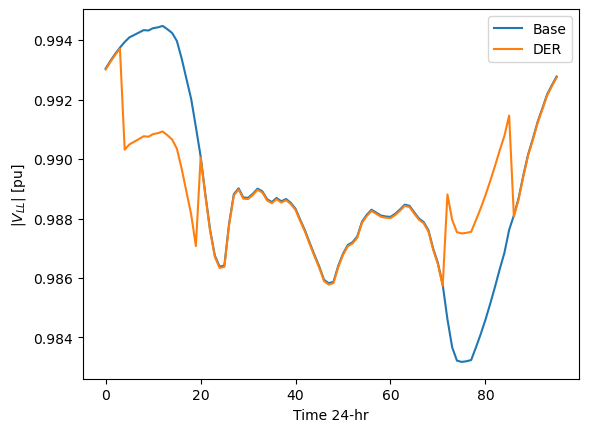

In [17]:
ht.plt.plot(groups_data[10], label="Base")
ht.plt.plot(groups_data[11], label="DER")
ht.plt.legend()
ht.plt.ylabel(r"|$V_{LL}$| [pu]")
ht.plt.xlabel("Time 24-hr")
ht.plt.show()

Este comportamiento se puede comprender mejor a la luz del concepto de **Carga a la Impedancia Característica de la Línea** o *Surge Impedance Loading* (SIL), que representa una condición de carga en la que no se requiere intercambio de potencia reactiva entre la línea y la red, manteniéndose así una tensión más estable a lo largo de la línea. Cuando una línea opera **por encima del SIL** —como suele ocurrir durante la noche, con baja demanda— la línea entrega potencia reactiva; cuando opera **por debajo del SIL**, la línea la absorbe. Ambas condiciones pueden generar variaciones indeseadas de tensión y, eventualmente, ineficiencias operativas.

Al incorporar un SAEB aguas abajo, con despacho coordinado, se mitigan estos efectos. Por un lado, el sistema reduce la absorción de reactivo en las horas de alta carga, y por otro, atenúa la sobrecompensación durante la noche, promoviendo una operación más cercana al SIL. Esta *autorregulación distribuida* suaviza los perfiles de tensión en el tiempo y en el espacio, como lo evidencian los boxplots menos dispersos, y reduce tanto los picos como los valles de tensión en la red.

En términos energéticos, esto se traduce en una **mejora de la eficiencia del sistema**. Al reducir el flujo de potencia reactiva innecesaria, disminuyen también las pérdidas activas asociadas al transporte de corriente, particularmente durante picos de carga. Además, una tensión más estable reduce el estrés operativo sobre equipos sensibles —como transformadores o inversores— prolongando su vida útil y disminuyendo la necesidad de sobredimensionamiento.

En suma, el efecto combinado de:

* menores pérdidas técnicas (activas y térmicas),
* menor generación de reactivo desde la subestación,
* perfiles de tensión más uniformes,
* y operación más cercana al SIL,

constituye una evidencia del valor técnico que tecnologías como el SAEB pueden aportar al sistema eléctrico, especialmente en redes desbalanceadas con arquitectura radial.

## Estudio de fallas <a class="anchor" id="fourth-section"></a>

Se consideran los tipos de fallas:

* Falla trifásica de línea a línea a tierra (**LLLG**): Las tres fases (nodos 1, 2 y 3) están conectadas a tierra (nodo 0). Este es el tipo de falla más grave, ya que crea un cortocircuito entre las tres fases y tierra simultáneamente. Aunque en los próximos resultados parezca menor en magnitud los cierto es que sólo se reportan las corrientes de cortocircuito *por fase*, luego al tratarse de una falla balanceada la potencia que impone en realidad es tres veces más.
* Falla de Línea a Tierra (**LG** o SLG): Este es el tipo de falla más común en los sistemas eléctricos, representando una sola fase (fase A, nodo 1) que hace contacto con tierra. Representa entre el 70 % y el 80 % de todas las fallas en los sistemas de distribución.
* Falla Doble Línea-Tierra Tipo A (**LLG_a**): Representa una falla en la que dos fases (A y B, representadas como nodos 1 y 2) están conectadas entre sí y a tierra.
* Falla Doble Línea-Tierra Tipo B (**LLG_b**): Representa una falla en la que dos fases (fases A y B, nodos 1 y 2) están conectadas simultáneamente a tierra, creando rutas paralelas (separadas) a tierra a través de ambas fases.
* Falla Línea a Línea (**LL**): Representa una falla entre dos fases (fases A y B, nodos 1 y 2) sin conexión a tierra. Se implementa como un objeto de falla monofásica conectado entre dos fases diferentes. No implica referencia a tierra, lo que la diferencia de las fallas LLG.

Las figuras a continuación alumbran corrientes de falla por cortocircuito contra la distancia [km], a partir de la subestación hasta la barra más alejada geométricamente, atravesadas por su respectiva regresión lineal para una comparación más estricta entre escenarios.



In [18]:
_ = base_ckt.fault_network()
_ = der_ckt.fault_network()

In [19]:
base_faults, base_buses = base_ckt.get_fault_currents()
bess_faults, bess_buses = der_ckt.get_fault_currents()


In [20]:
def linear_eq(
        x_vect: ht.np.ndarray,
        y_vect: ht.np.ndarray
) -> float:
    """Return ``m`` and ``b`` linear parameters.

    Compute slope :math:`m` and interception :math:`b`
    of short circuit current against distance.
    """
    # Calculate the mean of x and y
    x_mean = ht.np.mean(x_vect)
    y_mean = ht.np.mean(y_vect)

    # Calculate the slope (m)
    numerator = ht.np.sum((x_vect - x_mean) * (y_vect - y_mean))
    denominator = ht.np.sum((x_vect - x_mean)**2)
    m = numerator / denominator
    b = y_mean - m*x_mean
    return m, b


In [21]:
mv_buses_id = base_ckt.mv_buses_id
lv_buses_id = base_ckt.lv_buses_id
mv_indices: list[list] = []
lv_indices: list[list] = []

for faulted in base_buses:
    mv_i = []
    lv_i = []
    for i, bus in enumerate(faulted):
        if bus in mv_buses_id:
            mv_i.append(i)
        elif bus in lv_buses_id:
            lv_i.append(i)
        else:
            pass
    mv_indices.append(mv_i)
    lv_indices.append(lv_i)


### Fallas en media tensión <a class="anchor" id="mv-faults"></a>

Se aprecia de la figura [] que para cualquier falla la regresión lineal del caso DER $l_{\text{DER}}$ es prácticamente paralela a la base $l_{\text{base}}$, luego

$$
l_{\text{DER}} = l_{\text{base}} + \delta \quad ; \quad \delta > 0
$$

O sea simplemente hay un corrimiento vertical hacia arriba, esto sugiere que la presencia de DER introduce un incremento sistemático en la magnitud de las corrientes de falla a lo largo del circuito, sin alterar sustancialmente la tendencia espacial dictada por la impedancia de Thevenin.
Se nota también, al menos en zona de media tensión, que la tendencia es decreciente pues cuanto más alejado el punto de falla de la subestación, mayor será la impedancia de Thevenin vista desde la fuente. En consecuencia, la corriente de cortocircuito disminuye progresivamente con la distancia, como es típico en redes radiales.

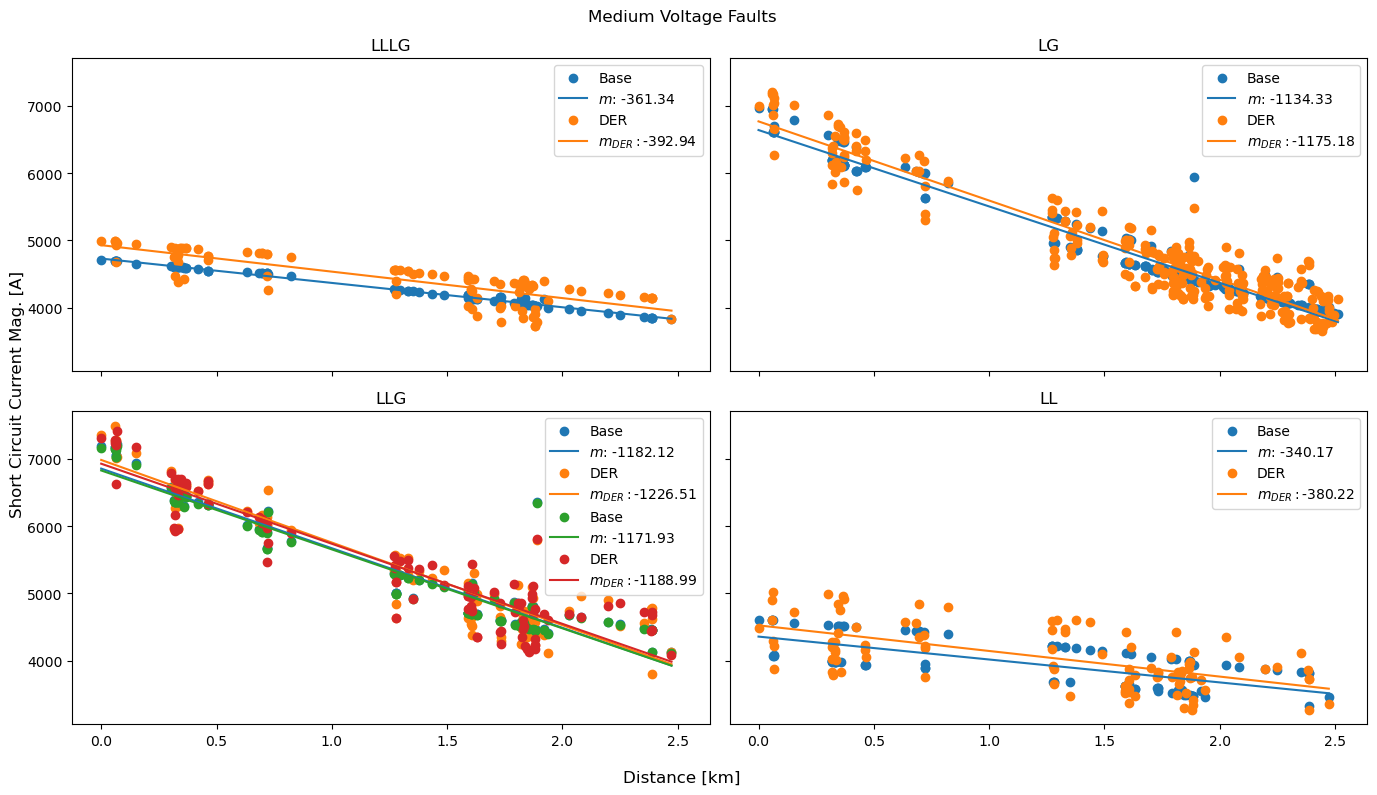

In [22]:
fault_types = ["LLLG", "LG", "LLG", "LLG", "LL"]

fig, axs = ht.plt.subplots(
    2, 2, sharex=True, sharey=True, figsize=(14, 8)
)
indx = {
    0: (0, 0),  # LLLG
    1: (0, 1),  # LG
    2: (1, 0),  # LLG a
    3: (1, 0),  # LLG b
    4: (1, 1)   # LL
}

for n, fault in enumerate(fault_types):
    # Base
    x = base_faults[n][mv_indices[n][:], 1]  # Distance [km]
    y = base_faults[n][mv_indices[n][:], 0]  # Current [A]
    m, b = linear_eq(x, y)
    axs[indx[n]].scatter(x, y, label="Base")
    axs[indx[n]].plot(x, m*x+b, label=r"$m$: "+f"{m:.2f}")
    axs[indx[n]].set_title(fault)
    axs[indx[n]].legend()
    # DER
    u = bess_faults[n][mv_indices[n][:], 1]  # Distance [km]
    v = bess_faults[n][mv_indices[n][:], 0]  # Current [A]
    p, q = linear_eq(u, v)
    axs[indx[n]].scatter(u, v, label="DER")
    axs[indx[n]].plot(u, p*u+q, label=r"$m_{DER}: $"+f"{p:.2f}")
    axs[indx[n]].set_title(fault)
    axs[indx[n]].legend()


fig.suptitle(r"Medium Voltage Faults")
fig.supxlabel("Distance [km]")
fig.supylabel("Short Circuit Current Mag. [A]")
fig.tight_layout()
ht.plt.show()

### Fallas en baja tensión <a class="anchor" id="lv-faults"></a>

En el nivel de baja tensión, se observa una regresión lineal relativamente constante en torno a los **2000 A** para ambos escenarios (con y sin DER), lo cual indica una escasa variabilidad de las corrientes de falla a lo largo del circuito. Esta estabilidad se debe, en parte, a que la impedancia en baja tensión es predominantemente local y las trayectorias eléctricas son cortas, lo que atenúa el efecto de la distancia geométrica desde la subestación.

Además, se aprecia que la densidad de fallas —especialmente las no trifásicas— tiende a incrementarse en zonas alejadas de la subestación. Esta tendencia responde a la propia topología del sistema de distribución en baja tensión, donde se conectan numerosas derivaciones monofásicas y bifásicas orientadas a clientes residenciales.

Como es de esperarse, hay **pocas barras trifásicas en baja tensión**, usualmente asociadas a cargas comerciales o industriales. No obstante, resultan llamativos algunos **picos aislados** de corriente de falla que se apartan significativamente de la tendencia general, alcanzando valores tan altos como **12,581.56 A** para el caso de una falla $LLG_a$. Estos saltos atípicos se explican por la **presencia de generación distribuida conectada directamente en dichas barras**, incluso en el escenario base, lo cual aumenta significativamente la contribución a la corriente de cortocircuito.


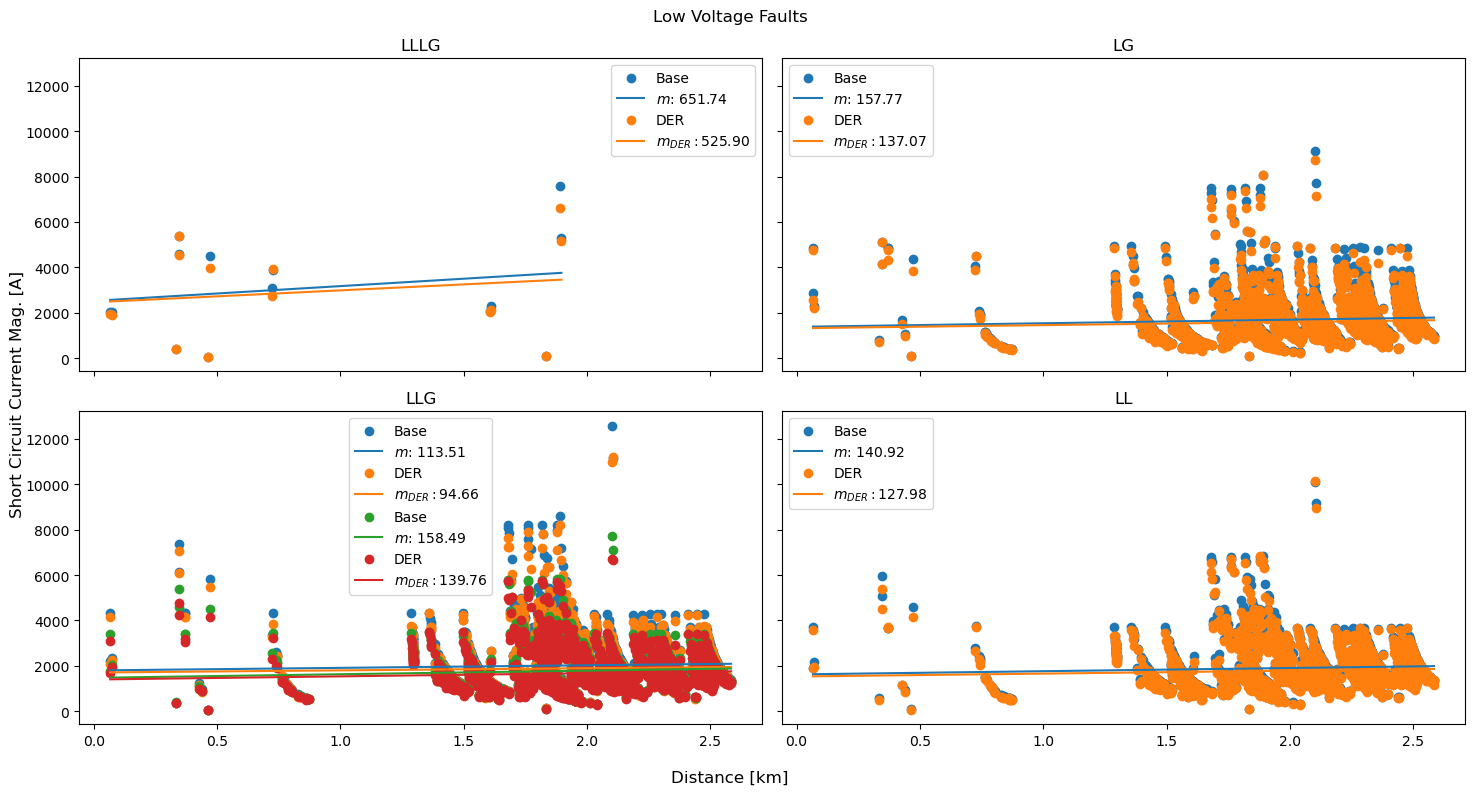

In [23]:
fig, axs = ht.plt.subplots(
    2, 2, sharex=True, sharey=True, figsize=(15, 8)
)
indx = {
    0: (0, 0),  # LLLG
    1: (0, 1),  # LG
    2: (1, 0),  # LLG a
    3: (1, 0),  # LLG b
    4: (1, 1)   # LL
}

for n, fault in enumerate(fault_types):
    # Base
    x = base_faults[n][lv_indices[n][:], 1]  # Distance [km]
    y = base_faults[n][lv_indices[n][:], 0]  # Current [A]
    m, b = linear_eq(x, y)
    axs[indx[n]].scatter(x, y, label="Base")
    axs[indx[n]].plot(x, m*x+b, label=r"$m$: "+f"{m:.2f}")
    axs[indx[n]].set_title(fault)
    axs[indx[n]].legend()
    # DER
    u = bess_faults[n][lv_indices[n][:], 1]  # Distance [km]
    v = bess_faults[n][lv_indices[n][:], 0]  # Current [A]
    p, q = linear_eq(u, v)
    axs[indx[n]].scatter(u, v, label="DER")
    axs[indx[n]].plot(u, p*u+q, label=r"$m_{DER}: $"+f"{p:.2f}")
    axs[indx[n]].set_title(fault)
    axs[indx[n]].legend()


fig.suptitle(r"Low Voltage Faults")
fig.supxlabel("Distance [km]")
fig.supylabel("Short Circuit Current Mag. [A]")
fig.tight_layout()
ht.plt.show()

### Exploring *odd* fault currents

- Maximum fault current all across the circuit

In [24]:
n_faults = len(base_faults)
max_indices = [
    ht.np.argmax(base_faults[n][:, 0])
    for n in range(n_faults)
]

for fault, i in enumerate(max_indices):
    print(f"BusID: {base_buses[fault][i]}")
    print(f"\tCurrent [A]: {base_faults[fault][i, 0]}")

BusID: buslvnoccad3730-b715-4e6a-9f5e-475966d4924bcplvpcn
	Current [A]: 7601.137271294856
BusID: buslvno7c749878-b965-45a9-8c11-599e650b0025cplvpcn
	Current [A]: 9126.321694441862
BusID: buslvno7c749878-b965-45a9-8c11-599e650b0025cplvpcn
	Current [A]: 12581.560569424533
BusID: buslvno7c749878-b965-45a9-8c11-599e650b0025cplvpcn
	Current [A]: 7701.330730882492
BusID: buslvno7c749878-b965-45a9-8c11-599e650b0025cplvpcn
	Current [A]: 10097.074694907229


## Curvas de tiempo para coordinación de protecciones <a class="anchor" id="protection-curves"></a>

## Conclusiones <a class="anchor" id="end"></a>

En cuanto a la viabilidad del modelo y calibración se refiere, la validación del modelo virtual frente a la demanda medida mostró un comportamiento muy cercano, con una potencia pico simulada de 21.53 MW frente a los 20.80 MW reales. Esta ligera sobredimensión es deliberada para garantizar márgenes de seguridad y fortalece la confiabilidad de los análisis posteriores. Así mismo la integración del SAEB aguas abajo de la subestación condujo a una disminución de 200 kW en las pérdidas activas diarias (de 25.50 MW en el caso base a 25.30 MW con DER es decir un 1% menos), gracias a la menor necesidad de potencia real al mejorar la condición de ángulo de carga y al soporte reactivo local, lo que permitió reducir en principio un 1 % la generación de VAr desde la subestación y, por ende, disminuir el flujo reactivo innecesario en la red.

Los diagramas de caja mostraron perfiles de tensión más compactos y menos dispersos con DER, especialmente aguas abajo del SAEB. La operación más cercana al Surge Impedance Loading (SIL) favorece una autorregulación distribuida que atenúa tanto los picos nocturnos como las caídas diurnas. La tensión más estable reduce el estrés sobre equipos sensibles (transformadores, inversores) y reduce la necesidad de sobredimensionamiento, alargando la vida útil de los activos y mejorando la eficiencia operativa.

En media tensión, la presencia de DER desplaza ligeramente hacia arriba la regresión de las corrientes de falla sin alterar su tendencia decreciente con la distancia. En baja tensión, las corrientes de falla se mantienen alrededor de 2000 A, con picos aislados en barras con DER del caso base (fotovoltaico principalmente), lo que destaca la importancia de un estudio de coordinación de protecciones.

En conjunto, estos hallazgos evidencian que la incorporación de un Sistema de Almacenamiento de Energía con Batería (SAEB) en redes desbalanceadas de media y baja tensión aporta beneficios técnicos significativos: disminución de pérdidas activas, soporte reactivo local, perfiles de tensión más uniformes y un impacto gestionable en la dinámica de fallas. Este enfoque potencia la resiliencia y eficiencia del sistema eléctrico al favorecer una operación más estable y segura.


---

## Referencias y Documentación <a class="anchor" id="references"></a>

[1] [DERify](https://github.com/MarioPeraltaA/DERify) <br>
[2] [OpenDSS Manual](https://opendss.epri.com/CircuitModelConcept.html) <br>
[3] [COM Interface](https://dss-extensions.org/index.html) <br>

---